In [76]:
import pandas as pd

# Task 1 - Data Loading and Exploration

### Loading Dataset

In [77]:
data = pd.read_csv("Housing.csv")

In [78]:
# printing first 10 rows

data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [79]:
rows,columns = data.shape

print("Number of rows in dataset:",rows)
print("Number of columns in dataset:",columns)

Number of rows in dataset: 545
Number of columns in dataset: 13


#### First column ie price is target columns and all other are features

In [80]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [81]:
# no any column has null or missing values

In [82]:
data.duplicated().sum()

np.int64(0)

In [83]:
# This means no any row is repeated

In [84]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


# Task 2 - Data Cleaning

## Encoding

In [85]:
data["furnishingstatus"].value_counts()  # has three categories

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [86]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
# import onehotencoder

from sklearn.preprocessing import OneHotEncoder

In [88]:
encoder = OneHotEncoder(drop="first",sparse_output=False)  # drop first to avoid problem like Dummy Variable Trap.

In [89]:
categorical_cols = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea","furnishingstatus"]

encoded = encoder.fit_transform(data[categorical_cols])  # its a numpy array 

In [90]:
encoded

array([[1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 1., ..., 1., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.]], shape=(545, 8))

In [91]:
# convert numpy array to dataframe

encoded_df = pd.DataFrame(
    encoded,
    columns = encoder.get_feature_names_out(categorical_cols) # extract name of columns
)

encoded_df.head()

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [92]:
# now combine these columns to org data and drop previus ones
data = data.drop(categorical_cols,axis=1)

In [93]:
final_data = pd.concat([data,encoded_df],axis=1)

In [94]:
final_data.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,12250000,8960,4,4,4,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,12250000,9960,3,2,2,2,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,12215000,7500,4,2,2,3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,11410000,7420,4,1,2,2,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [95]:
# converting double values to int

dummy_cols = [
    'mainroad_yes',
    'guestroom_yes',
    'basement_yes',
    'hotwaterheating_yes',
    'airconditioning_yes',
    'prefarea_yes',
    'furnishingstatus_semi-furnished',
    'furnishingstatus_unfurnished'
]

final_data[dummy_cols] = final_data[dummy_cols].astype(int)  

final_data.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


#### All Columns are meaning ful for predicting house price so nothing to remove

In [96]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Correlation heatmap

In [97]:
correlation = final_data.corr()

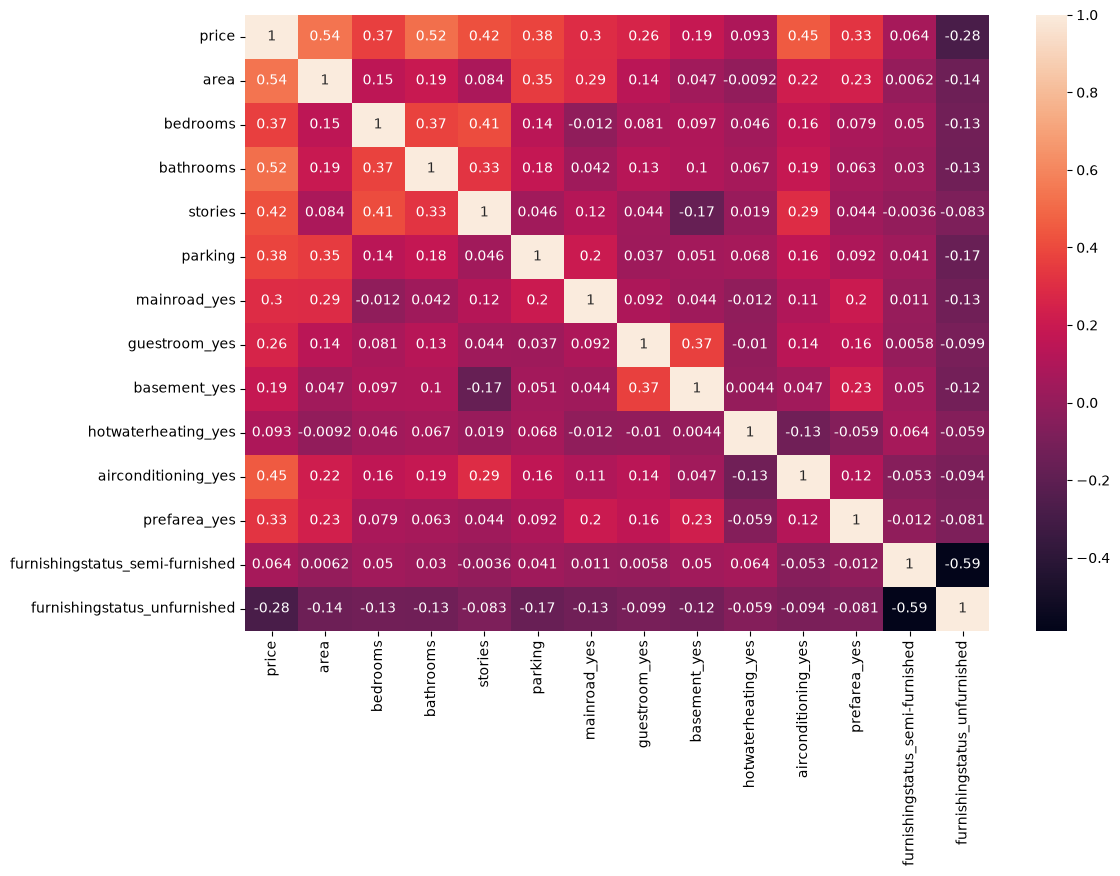

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))  # increase size of heat map
sns.heatmap(correlation,annot=True)
plt.show()

# Task 3 - Model Building

## Spliting the Data 

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
X = final_data.drop(columns=["price"])
y = final_data["price"]

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)  # random_state -> to get same train test data every time

## Models Training 

### 1. Linear Regression

In [101]:
from sklearn.linear_model import LinearRegression 

#### Scaling the data

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [104]:
LinearReg = LinearRegression()

LinearReg.fit(X_train_scale,y_train)

y_LR_pred = LinearReg.predict(X_test_scale)

In [105]:
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error

print("R2 score of linear Reg model:",r2_score(y_test,y_LR_pred))
print("MAE score of linear Reg model:",mean_absolute_error(y_test,y_LR_pred))
print("RMSE score of linear Reg model:",root_mean_squared_error(y_test,y_LR_pred))


R2 score of linear Reg model: 0.6631280462200979
MAE score of linear Reg model: 915955.8864463974
RMSE score of linear Reg model: 1245949.129409001


### 2. Random forest Regressor

In [106]:
from sklearn.ensemble import RandomForestRegressor 

In [108]:
Random_For_Reg = RandomForestRegressor(n_estimators = 100,
                                       max_depth=10,
                                       min_samples_split=5,
                                       min_samples_leaf=2,
                                       random_state=42)

Random_For_Reg.fit(X_train,y_train)

y_rfg_pred = Random_For_Reg.predict(X_test)

In [109]:
print("R2 score of Random forest:",r2_score(y_test,y_rfg_pred))
print("MAE score of Random forest:",mean_absolute_error(y_test,y_rfg_pred))
print("RMSE score of Random forest:",root_mean_squared_error(y_test,y_rfg_pred))


print(Random_For_Reg.score(X_train,y_train))
print(Random_For_Reg.score(X_test,y_test))

R2 score of Random forest: 0.5924140271771625
MAE score of Random forest: 1005612.1370697517
RMSE score of Random forest: 1370495.1340103203
0.8774604655239308
0.5924140271771625


#### As the model is overfitting the data -> now doing hyper tunning in another way

In [110]:
rf = RandomForestRegressor(n_estimators = 1000,
                                       max_depth=None,
                                       min_samples_split=10,
                                       min_samples_leaf=5,
                                       random_state=42)

rf.fit(X_train,y_train)

y_rfg_pred = rf.predict(X_test)

In [111]:
print("R2 score of Random forest:",r2_score(y_test,y_rfg_pred))
print("MAE score of Random forest:",mean_absolute_error(y_test,y_rfg_pred))
print("RMSE score of Random forest:",root_mean_squared_error(y_test,y_rfg_pred))

print(rf.score(X_train,y_train))
print(rf.score(X_test,y_test))

R2 score of Random forest: 0.5917882530796577
MAE score of Random forest: 1035701.1611065925
RMSE score of Random forest: 1371546.803455833
0.7671997868426532
0.5917882530796577


#### Hyperparameter tuning reduced the overfitting of the Random Forest model by narrowing the gap between training and testing performance, leading to better generalization.

### 3. Ridge Regression

In [112]:
from sklearn.linear_model import Ridge

In [113]:
ridge = Ridge(alpha=1)

ridge.fit(X_train_scale, y_train)

y_ridge_pred = ridge.predict(X_test_scale)

In [114]:
print("R2 score of Ridge Regression:",r2_score(y_test,y_ridge_pred))
print("MAE score of Ridge Regression:",mean_absolute_error(y_test,y_ridge_pred))
print("RMSE score of Ridge Regression:",root_mean_squared_error(y_test,y_ridge_pred))

R2 score of Ridge Regression: 0.6630998620593584
MAE score of Ridge Regression: 915639.7454249043
RMSE score of Ridge Regression: 1246001.249058149


### 4. Lasso Regression

In [115]:
from sklearn.linear_model import Lasso

In [116]:
lasso = Lasso(alpha=100)

lasso.fit(X_train_scale,y_train)

y_lasso_pred = lasso.predict(X_test_scale)

In [117]:
print("R2 score of Lasso Regression:",r2_score(y_test,y_lasso_pred))
print("MAE score of Lasso Regression:",mean_absolute_error(y_test,y_lasso_pred))
print("RMSE score of Lasso Regression:",root_mean_squared_error(y_test,y_lasso_pred))

R2 score of Lasso Regression: 0.663117842569285
MAE score of Lasso Regression: 915923.1001619556
RMSE score of Lasso Regression: 1245967.9987945894


# Task 4 - Visualization

In [131]:
import matplotlib.pyplot as plt
import os
os.makedirs("charts", exist_ok=True)

### Chart 1 

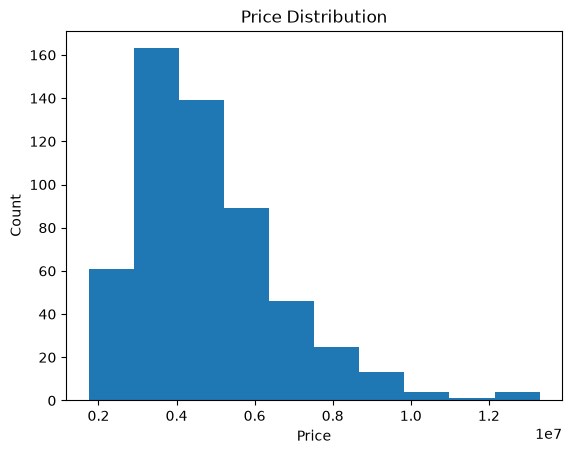

In [145]:
plt.hist(final_data["price"])
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.savefig("Price_Distribution.png")
plt.show()

### Chart 2

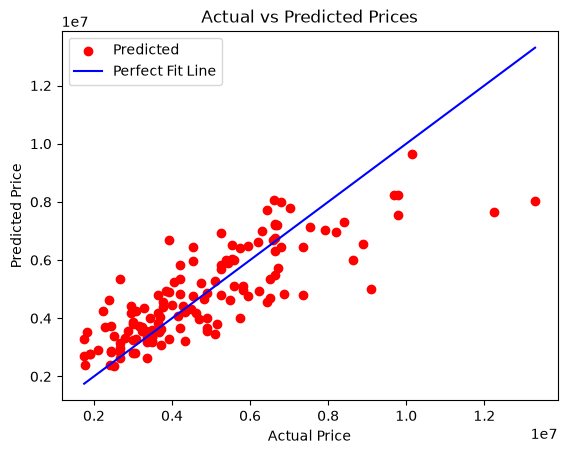

In [146]:
plt.scatter(y_test, y_LR_pred, color='red',label='Predicted')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='blue', label='Perfect Fit Line')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()

In [121]:
print("Max value predicted by model:",y_LR_pred.max())
print("Actual max value in testing data:",y_test.max())

Max value predicted by model: 9645189.758499768
Actual max value in testing data: 13300000


### Chart 3

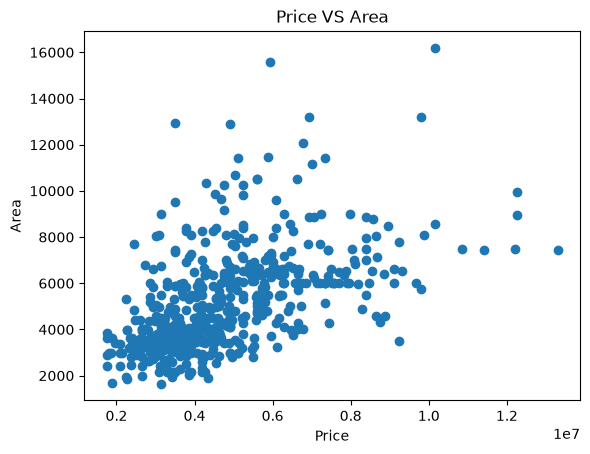

In [147]:
plt.scatter(final_data["price"],final_data["area"])

plt.xlabel("Price")
plt.ylabel("Area")
plt.title("Price VS Area")
plt.show()

### Chart 4 

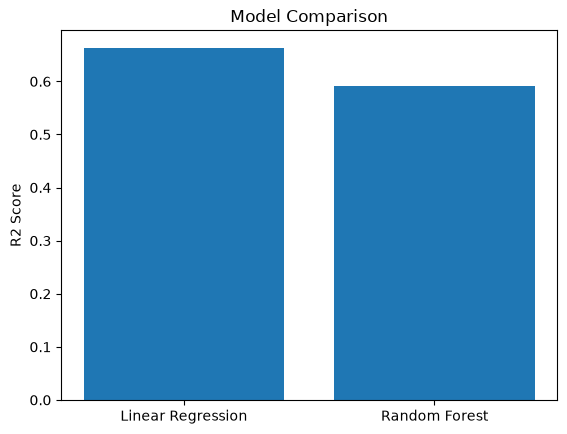

In [149]:
r2_scores = [0.663,0.592]

models = ["Linear Regression","Random Forest"]

plt.bar(models,r2_scores)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

# Task 5 - Insights and Summary

1. The most important feature influencing house price is **area**. It has the strongest positive relationship with price, meaning larger houses generally cost more. Other features like bathrooms, air conditioning, and stories also affect price, but their impact is smaller compared to area.

2. The model achieved an R² score of around 0.66, which means it explains about **66%** of the variation in house prices. In simple terms, the predictions are fairly close to the actual values but not perfectly accurate. The model has an average error of around 9 lakh rupees (MAE), which shows that some predictions still deviate noticeably from real prices.

3. One surprising observation in the data was that the relationship between features and house price is mostly linear. Because of this, simpler models like **Linear Regression** performed better than more complex models such as Random Forest. In addition, regularized linear models like **Ridge** and **Lasso** also performed well and gave stable results compared to more complex models. This shows that the dataset is best captured by linear relationships rather than highly complex patterns. It also indicates that not all features strongly influence the target variable.

4. A key recommendation for a real estate business is to focus primarily on the area of the property when deciding house prices, as it has the strongest influence on price. Properties with larger area tend to have significantly higher value. Other important factors such as number of bathrooms and essential amenities like air conditioning and stpries should also be considered. Businesses can use these features to set more accurate and competitive pricing strategies.